# Stage 13 — Scientific interpretation

_Pipeline stage 13 of `docs/PIPELINE_DESIGN.md`. Uses the canonical `channel_heads` package + on-disk artifacts; heavy rebuilds run via the `channel-heads` CLI (see each stage's command)._

## What Mars is telling us

We read the result scientifically: how much of the martian valley network is
**coupled**, how that splits across networks, and how regime-robust it is. High
coupling indicates divides that were mobile while the valleys were active — a more
Earth-like, dynamic fluvial regime.

In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import channel_heads as ch
from channel_heads.io.paths import PROJECT_ROOT, RESULTS_DIR, EXAMPLE_DEMS
ROOT     = PROJECT_ROOT
MODELS   = ROOT / 'models'
MARS_OUT = ROOT / 'data/Mars/model_outputs'
MARS_IN  = ROOT / 'data/Mars/model_inputs'
REGIMES_ = ['regA', 'regB', 'regC']
# Frozen model features (5 dimensionless) + operating thresholds (Stage 9).
MODEL_FEATURES = ['orientation_diff_deg','headhead_dist_norm','apex_angle_deg',
                  'strahler_order_diff','proximity_profile_norm']
OP_THR = {'regA': 0.756326, 'regB': 0.779264, 'regC': 0.759369}
print('channel_heads', ch.__version__, '| root', ROOT)


channel_heads 0.1.0 | root /Users/guypi/Projects/channel-heads


In [2]:
p = MARS_OUT / 'mars_regime_interpretation.csv'
display(pd.read_csv(p) if p.exists() else pd.DataFrame())

,regime,operating_threshold,n_pairs,n_networks,touching_frac,high_conf_frac_ge0.8,mean_prob,networks_with_any_touch,frac_networks_with_touch,mean_per_network_touch_frac
0,regA,0.756326,3682,391,0.5304,0.4574,0.6676,382,0.9770,0.5709
1,regB,0.779264,3682,391,0.6407,0.6165,0.7388,383,0.9795,0.6820
2,regC,0.759369,3682,391,0.3859,0.3430,0.5950,372,0.9514,0.4427


### Cross-regime consensus (how regime-robust is each pair's call?)

In [3]:
base = None
for r in REGIMES_:
    p = MARS_OUT / f'mars_combined_{r}_predictions.parquet'
    if not p.exists(): continue
    d = pd.read_parquet(p)[['pair_id', 'prob_touching']].copy()
    d[r] = (d['prob_touching'] >= OP_THR[r]).astype(int)
    d = d[['pair_id', r]]
    base = d if base is None else base.merge(d, on='pair_id')
if base is not None:
    s = base[REGIMES_].sum(axis=1); n = len(base)
    print(f'pairs={n}')
    print(f'  all 3 TOUCHING     : {int((s==3).sum())} ({100*(s==3).mean():.1f}%)')
    print(f'  all 3 NON-touching : {int((s==0).sum())} ({100*(s==0).mean():.1f}%)')
    print(f'  consensus          : {100*((s==0)|(s==3)).mean():.1f}%')
    print(f'  regime-sensitive   : {100*((s>0)&(s<3)).mean():.1f}%')

pairs=3682
  all 3 TOUCHING     : 1250 (33.9%)
  all 3 NON-touching : 1133 (30.8%)
  consensus          : 64.7%
  regime-sensitive   : 35.3%


### Per-network coupled fraction (regA)

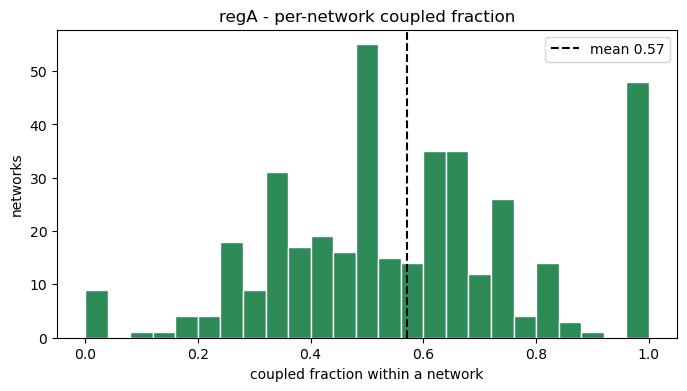

In [4]:
d = pd.read_parquet(MARS_OUT / 'mars_combined_regA_predictions.parquet')
per = d.groupby('network_id').pred_touching.mean()
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(per, bins=25, color='seagreen', edgecolor='white')
ax.axvline(per.mean(), color='k', ls='--', label=f'mean {per.mean():.2f}')
ax.set_xlabel('coupled fraction within a network'); ax.set_ylabel('networks')
ax.set_title('regA - per-network coupled fraction'); ax.legend(); plt.show()

Deep dive: `notebooks/interpretation/00_scientific_summary.ipynb`.